# Fruit Freshness Classification — ML Pipeline
**ALU BSE — Machine Learning Pipeline Summative**

This notebook covers the full ML lifecycle:
1. Data Acquisition
2. Data Preprocessing & EDA
3. Model Creation (VGG16 Transfer Learning)
4. Model Training
5. Model Evaluation
6. Model Testing & Prediction
7. Model Saving for Deployment

## 0. Install Dependencies

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn numpy pandas Pillow kaggle -q

## 1. Data Acquisition
Dataset: [Fruits Fresh and Rotten for Classification](https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip dataset from Drive
!unzip -q "/content/drive/MyDrive/MLPOS/archive (1).zip" -d /content/data/

print('Dataset ready!')

# Confirm structure
!ls /content/data/dataset/train

Mounted at /content/drive
Dataset ready!
freshapples  freshoranges  rottenbanana
freshbanana  rottenapples  rottenoranges


## 2. Imports & Configuration

In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Reproducibility seed ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Configuration ──
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 6   # freshApple, freshBanana, freshOrange, rottenApple, rottenBanana, rottenOrange

TRAIN_DIR = '/content/data/dataset/train'
TEST_DIR  = '/content/data/dataset/test'

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


## 3. Exploratory Data Analysis (EDA)

In [13]:
TRAIN_DIR = '/content/data/dataset/train'
TEST_DIR  = '/content/data/dataset/test'

def get_class_counts(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = get_class_counts(TRAIN_DIR)
test_counts  = get_class_counts(TEST_DIR)

print('Training set distribution:')
for cls, count in train_counts.items():
    print(f'  {cls}: {count} images')

print(f'\nTotal training images: {sum(train_counts.values())}')
print(f'Total test images:     {sum(test_counts.values())}')

Training set distribution:
  freshapples: 1693 images
  freshbanana: 1581 images
  freshoranges: 1466 images
  rottenapples: 2342 images
  rottenbanana: 2224 images
  rottenoranges: 1595 images

Total training images: 10901
Total test images:     2698


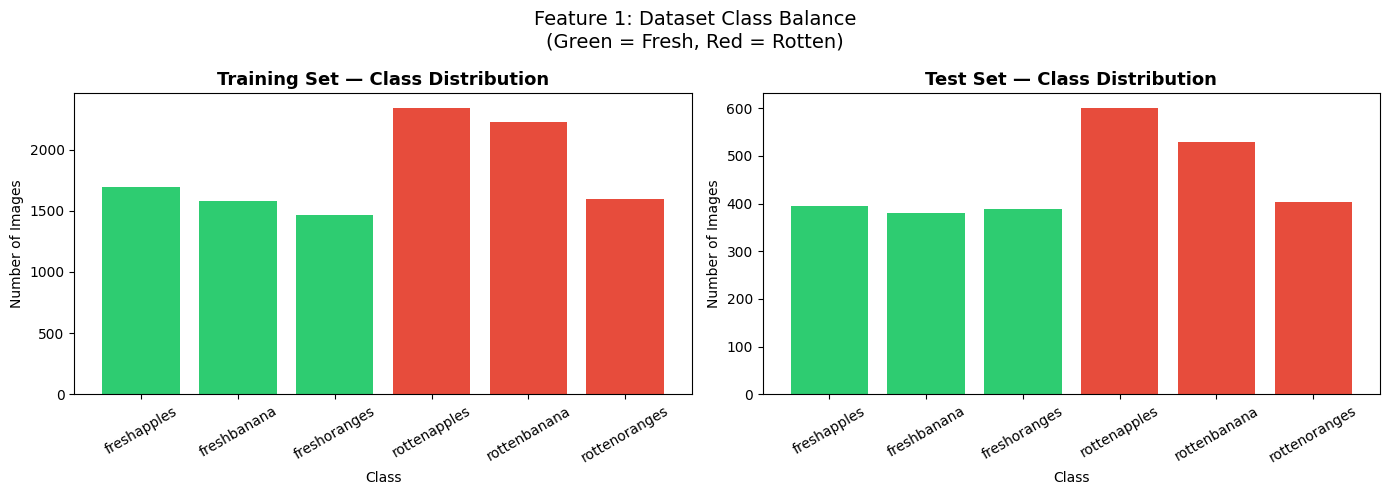


 Interpretation: The dataset is fairly balanced across all 6 classes.
Both fresh and rotten variants are well represented, reducing class bias risk.


In [14]:
# ── Feature 1: Class Distribution Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if 'fresh' in k else '#e74c3c' for k in train_counts.keys()]

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)

colors_test = ['#2ecc71' if 'fresh' in k else '#e74c3c' for k in test_counts.keys()]
axes[1].bar(test_counts.keys(), test_counts.values(), color=colors_test)
axes[1].set_title('Test Set — Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Feature 1: Dataset Class Balance\n(Green = Fresh, Red = Rotten)', fontsize=14)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Interpretation: The dataset is fairly balanced across all 6 classes.')
print('Both fresh and rotten variants are well represented, reducing class bias risk.')

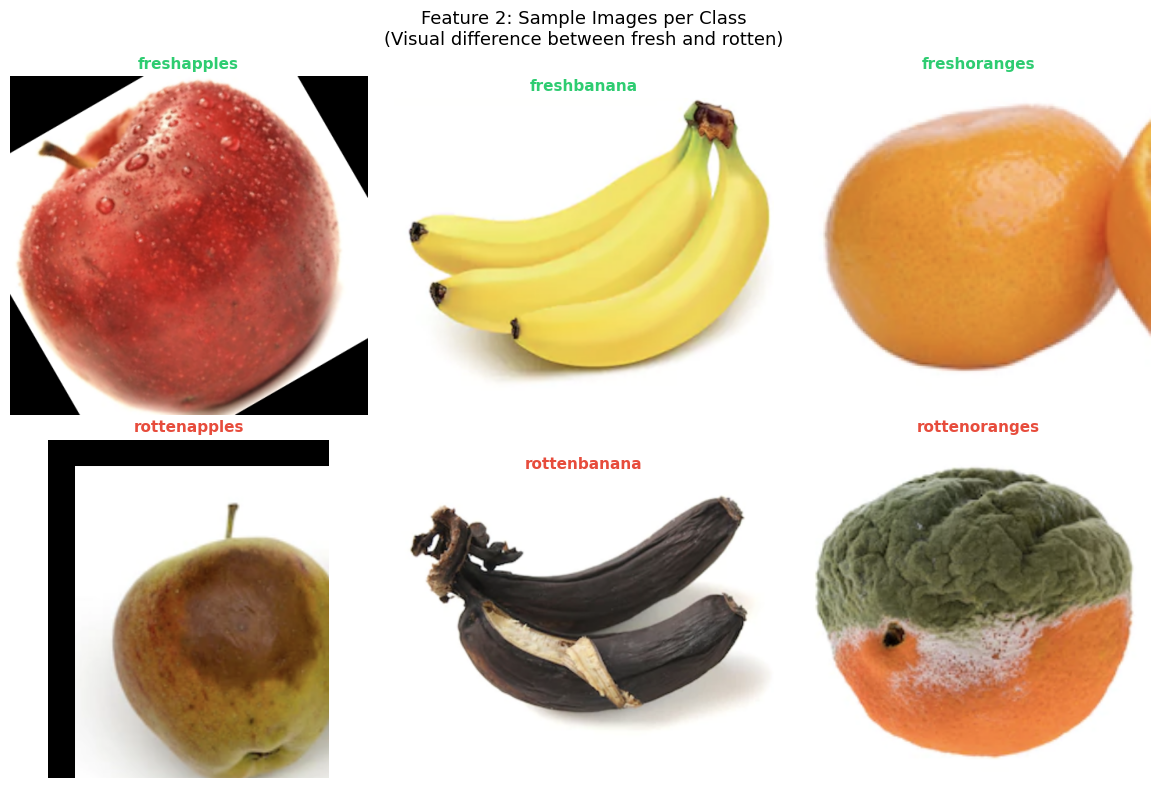


 Interpretation: Fresh fruits show vibrant colors and smooth textures.
Rotten fruits display discoloration, dark spots, and surface deterioration.
These visual cues are what the CNN model will learn to distinguish.


In [16]:
# ── Feature 2: Sample Images per Class ──
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, class_name in enumerate(sorted(train_counts.keys())):
    class_path = os.path.join(TRAIN_DIR, class_name)
    sample_img = random.choice(os.listdir(class_path))
    img = mpimg.imread(os.path.join(class_path, sample_img))
    axes[idx].imshow(img)
    color = '#2ecc71' if 'fresh' in class_name.lower() else '#e74c3c'
    axes[idx].set_title(class_name, fontsize=11, color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Feature 2: Sample Images per Class\n(Visual difference between fresh and rotten)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Interpretation: Fresh fruits show vibrant colors and smooth textures.')
print('Rotten fruits display discoloration, dark spots, and surface deterioration.')
print('These visual cues are what the CNN model will learn to distinguish.')

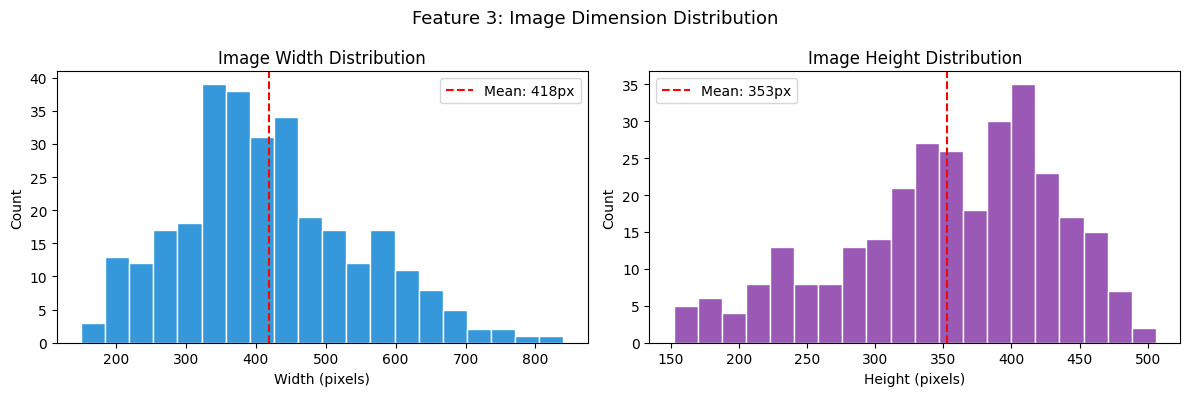


 Interpretation: Images vary in size (avg 418x353px).
Resizing all images to 224x224 during preprocessing standardizes input for VGG16.
This normalization step is critical for consistent model performance.


In [17]:
# Feature 3: Image Size Distribution
widths, heights = [], []

for class_name in train_counts.keys():
    class_path = os.path.join(TRAIN_DIR, class_name)
    for img_file in random.sample(os.listdir(class_path), min(50, len(os.listdir(class_path)))):
        try:
            img = Image.open(os.path.join(class_path, img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].legend()

axes[1].hist(heights, bins=20, color='#9b59b6', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].legend()

plt.suptitle('Feature 3: Image Dimension Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Interpretation: Images vary in size (avg {np.mean(widths):.0f}x{np.mean(heights):.0f}px).')
print('Resizing all images to 224x224 during preprocessing standardizes input for VGG16.')
print('This normalization step is critical for consistent model performance.')

## 4. Data Preprocessing

In [18]:
# Data Augmentation & Normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2   # 80/20 train-val split
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f'Classes: {class_names}')
print(f'Training batches:   {len(train_generator)}')
print(f'Validation batches: {len(val_generator)}')
print(f'Test batches:       {len(test_generator)}')

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Training batches:   273
Validation batches: 69
Test batches:       85


## 5. Model Creation — VGG16 Transfer Learning

In [19]:
def build_model(num_classes, img_size=(224, 224)):
    """Build VGG16-based transfer learning model for fruit freshness classification."""

    # Load VGG16 pretrained on ImageNet, exclude top classification layers
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )

    # Freeze base model layers (feature extraction phase)
    base_model.trainable = False

    # Build custom classification head
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model(NUM_CLASSES)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,286 (57.65 MB)

 Trainable params: 397,062 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

## 6. Model Training

In [20]:
# Callbacks
os.makedirs('models', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='models/fruit_model_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('Starting Phase 1: Feature Extraction (frozen base)...')
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Starting Phase 1: Feature Extraction (frozen base)...
Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.4357 - loss: 1.6054
Epoch 1: val_accuracy improved from None to 0.62764, saving model to models/fruit_model_best.h5



Epoch 1: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 234s 793ms/step - accuracy: 0.5708 - loss: 1.1918 - val_accuracy: 0.6276 - val_loss: 0.9966 - learning_rate: 1.0000e-04
Epoch 2/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7235 - loss: 0.7508
Epoch 2: val_accuracy improved from 0.62764 to 0.87098, saving model to models/fruit_model_best.h5



Epoch 2: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 196s 717ms/step - accuracy: 0.7505 - loss: 0.6874 - val_accuracy: 0.8710 - val_loss: 0.3601 - learning_rate: 1.0000e-04
Epoch 3/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.7871 - loss: 0.5869
Epoch 3: val_accuracy improved from 0.87098 to 0.91185, saving model to models/fruit_model_best.h5



Epoch 3: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 738ms/step - accuracy: 0.7985 - loss: 0.5497 - val_accuracy: 0.9118 - val_loss: 0.2490 - learning_rate: 1.0000e-04
Epoch 4/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8262 - loss: 0.4768
Epoch 4: val_accuracy improved from 0.91185 to 0.91322, saving model to models/fruit_model_best.h5



Epoch 4: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 214s 785ms/step - accuracy: 0.8319 - loss: 0.4577 - val_accuracy: 0.9132 - val_loss: 0.2241 - learning_rate: 1.0000e-04
Epoch 5/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8409 - loss: 0.4297
Epoch 5: val_accuracy improved from 0.91322 to 0.92700, saving model to models/fruit_model_best.h5


...


Epoch 8: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 207s 757ms/step - accuracy: 0.8753 - loss: 0.3362 - val_accuracy: 0.9550 - val_loss: 0.1325 - learning_rate: 1.0000e-04
Epoch 9/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.8874 - loss: 0.3106
Epoch 9: val_accuracy improved from 0.95500 to 0.95546, saving model to models/fruit_model_best.h5



Epoch 9: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 216s 790ms/step - accuracy: 0.8883 - loss: 0.3074 - val_accuracy: 0.9555 - val_loss: 0.1226 - learning_rate: 1.0000e-04
Epoch 10/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8846 - loss: 0.3108
Epoch 10: val_accuracy did not improve from 0.95546
273/273 ━━━━━━━━━━━━━━━━━━━━ 289s 889ms/step - accuracy: 0.8881 - loss: 0.2999 - val_accuracy: 0.9541 - val_loss: 0.1275 - learning_rate: 1.0000e-04
Epoch 11/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8998 - loss: 0.2764
Epoch 11: val_accuracy improved from 0.95546 to 0.95960, saving model to models/fruit_model_best.h5



Epoch 11: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 214s 786ms/step - accuracy: 0.8987 - loss: 0.2833 - val_accuracy: 0.9596 - val_loss: 0.1211 - learning_rate: 1.0000e-04
Epoch 12/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8958 - loss: 0.2869
Epoch 12: val_accuracy improved from 0.95960 to 0.96327, saving model to models/fruit_model_best.h5



Epoch 12: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 210s 769ms/step - accuracy: 0.8946 - loss: 0.2851 - val_accuracy: 0.9633 - val_loss: 0.1099 - learning_rate: 1.0000e-04
Epoch 13/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9072 - loss: 0.2533
Epoch 13: val_accuracy did not improve from 0.96327
273/273 ━━━━━━━━━━━━━━━━━━━━ 205s 752ms/step - accuracy: 0.9047 - loss: 0.2623 - val_accuracy: 0.9573 - val_loss: 0.1154 - learning_rate: 1.0000e-04
Epoch 14/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9029 - loss: 0.2566
Epoch 14: val_accuracy did not improve from 0.96327
273/273 ━━━━━━━━━━━━━━━━━━━━ 202s 742ms/step - accuracy: 0.9053 - loss: 0.2563 - val_accuracy: 0.9628 - val_loss: 0.1115 - learning_rate: 1.0000e-04
Epoch 15/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9083 - loss: 0.2544
Epoch 15: val_accuracy did not improve from 0.96327
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 735ms/step - accuracy: 0.9095 - l


Epoch 16: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 199s 727ms/step - accuracy: 0.9102 - loss: 0.2388 - val_accuracy: 0.9697 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 17/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9142 - loss: 0.2372
Epoch 17: val_accuracy did not improve from 0.96970
273/273 ━━━━━━━━━━━━━━━━━━━━ 203s 744ms/step - accuracy: 0.9142 - loss: 0.2361 - val_accuracy: 0.9596 - val_loss: 0.0970 - learning_rate: 1.0000e-04
Epoch 18/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9199 - loss: 0.2226
Epoch 18: val_accuracy did not improve from 0.96970
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 735ms/step - accuracy: 0.9178 - loss: 0.2199 - val_accuracy: 0.9674 - val_loss: 0.0916 - learning_rate: 1.0000e-04
Epoch 19/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9239 - loss: 0.2122
Epoch 19: val_accuracy did not improve from 0.96970
273/273 ━━━━━━━━━━━━━━━━━━━━ 200s 732ms/step - accuracy: 0.9222 - l

In [21]:
# Phase 2: Fine-tuning — unfreeze last 4 VGG16 layers
print('Starting Phase 2: Fine-tuning (partial unfreeze)...')

base_model = model.layers[0]
base_model.trainable = True

# Freeze all layers except last 4
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Starting Phase 2: Fine-tuning (partial unfreeze)...
Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9168 - loss: 0.2220
Epoch 1: val_accuracy improved from 0.96970 to 0.97750, saving model to models/fruit_model_best.h5



Epoch 1: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 216s 756ms/step - accuracy: 0.9273 - loss: 0.1963 - val_accuracy: 0.9775 - val_loss: 0.0633 - learning_rate: 1.0000e-05
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9504 - loss: 0.1381
Epoch 2: val_accuracy improved from 0.97750 to 0.98944, saving model to models/fruit_model_best.h5



Epoch 2: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 737ms/step - accuracy: 0.9533 - loss: 0.1341 - val_accuracy: 0.9894 - val_loss: 0.0391 - learning_rate: 1.0000e-05
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9654 - loss: 0.1006
Epoch 3: val_accuracy improved from 0.98944 to 0.99357, saving model to models/fruit_model_best.h5



Epoch 3: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 200s 732ms/step - accuracy: 0.9657 - loss: 0.0991 - val_accuracy: 0.9936 - val_loss: 0.0240 - learning_rate: 1.0000e-05
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9677 - loss: 0.0825
Epoch 4: val_accuracy did not improve from 0.99357
273/273 ━━━━━━━━━━━━━━━━━━━━ 197s 723ms/step - accuracy: 0.9688 - loss: 0.0832 - val_accuracy: 0.9917 - val_loss: 0.0267 - learning_rate: 1.0000e-05
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9779 - loss: 0.0678
Epoch 5: val_accuracy did not improve from 0.99357
273/273 ━━━━━━━━━━━━━━━━━━━━ 196s 719ms/step - accuracy: 0.9774 - loss: 0.0671 - val_accuracy: 0.9899 - val_loss: 0.0267 - learning_rate: 1.0000e-05
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9800 - loss: 0.0602
Epoch 6: val_accuracy did not improve from 0.99357
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 735ms/step - accuracy: 0.9799 - loss: 0.


Epoch 7: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 199s 728ms/step - accuracy: 0.9822 - loss: 0.0542 - val_accuracy: 0.9954 - val_loss: 0.0145 - learning_rate: 1.0000e-05
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9837 - loss: 0.0472
Epoch 8: val_accuracy did not improve from 0.99541
273/273 ━━━━━━━━━━━━━━━━━━━━ 201s 734ms/step - accuracy: 0.9842 - loss: 0.0486 - val_accuracy: 0.9904 - val_loss: 0.0302 - learning_rate: 1.0000e-05
Epoch 9/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9841 - loss: 0.0486
Epoch 9: val_accuracy improved from 0.99541 to 0.99816, saving model to models/fruit_model_best.h5



Epoch 9: finished saving model to models/fruit_model_best.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 200s 732ms/step - accuracy: 0.9854 - loss: 0.0444 - val_accuracy: 0.9982 - val_loss: 0.0081 - learning_rate: 1.0000e-05
Epoch 10/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9905 - loss: 0.0317
Epoch 10: val_accuracy did not improve from 0.99816
273/273 ━━━━━━━━━━━━━━━━━━━━ 199s 728ms/step - accuracy: 0.9893 - loss: 0.0341 - val_accuracy: 0.9972 - val_loss: 0.0108 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 9.


## 7. Training Curves

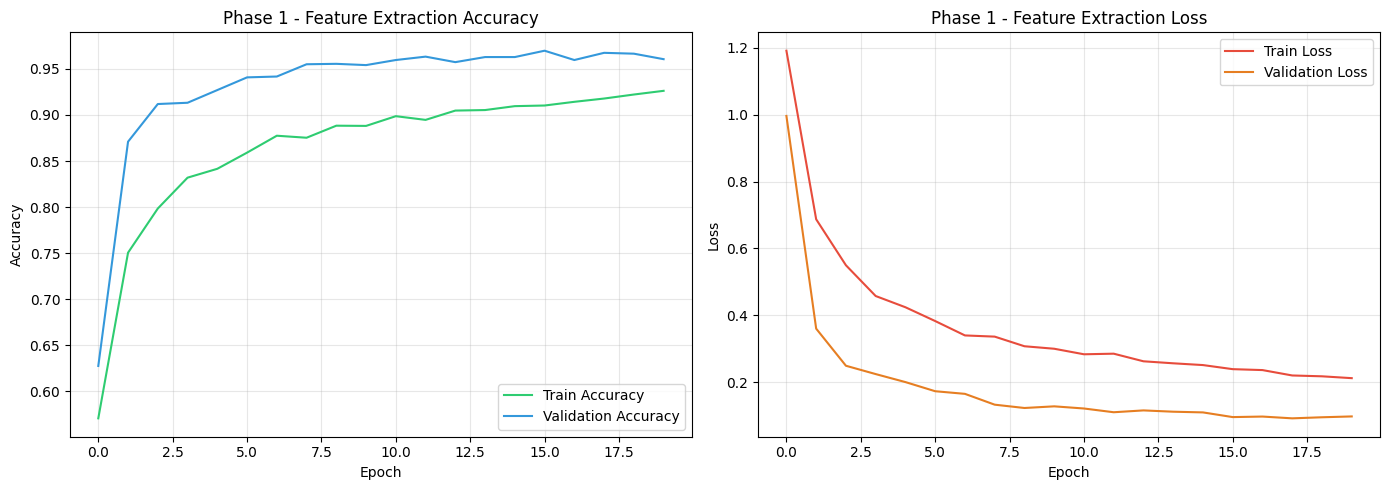

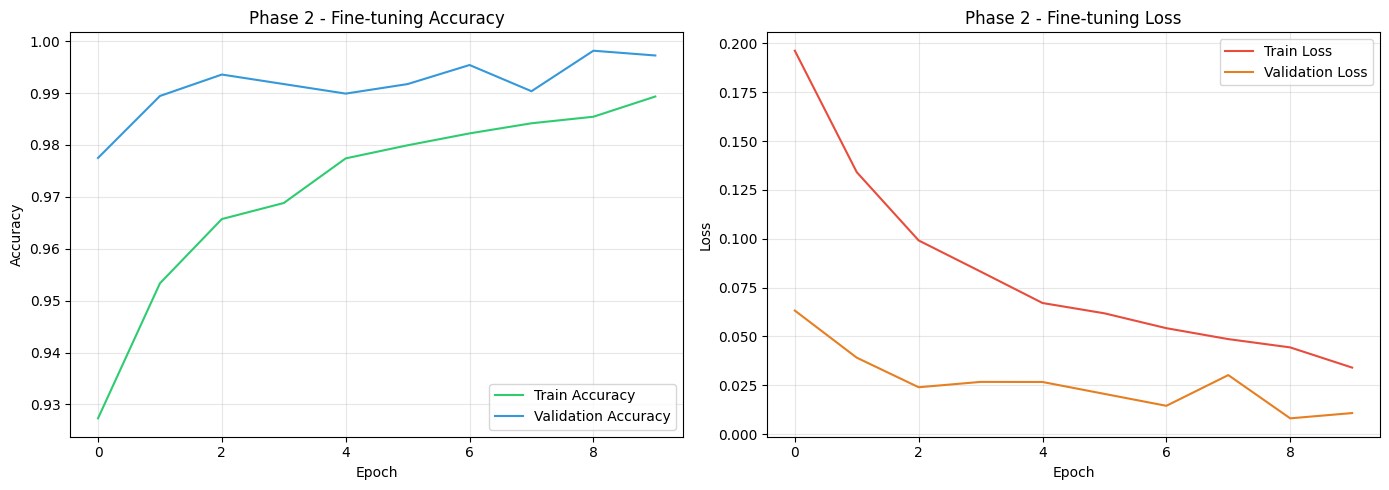

In [22]:
def plot_training_history(history, title_prefix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='#2ecc71')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',  color='#3498db')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',     color='#e74c3c')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#e67e22')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curves_{title_prefix.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_training_history(history, 'Phase 1 - Feature Extraction')
plot_training_history(history_finetune, 'Phase 2 - Fine-tuning')

## 8. Model Evaluation

In [23]:
# Test Set Evaluation
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'Test Loss:     {test_loss:.4f}')

85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 303ms/step - accuracy: 0.9981 - loss: 0.0099

Test Accuracy: 0.9981 (99.81%)
Test Loss:     0.0099


In [24]:
# Predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

# ── Classification Report ──
print('\nClassification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Aggregate Metrics ──
print('\nAggregate Metrics:')
print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
print(f'  Precision: {precision_score(y_true, y_pred, average="weighted"):.4f}')
print(f'  Recall:    {recall_score(y_true, y_pred, average="weighted"):.4f}')
print(f'  F1 Score:  {f1_score(y_true, y_pred, average="weighted"):.4f}')

85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 262ms/step

Classification Report:
               precision    recall  f1-score   support

  freshapples       0.99      1.00      1.00       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       1.00      1.00      1.00       388
 rottenapples       1.00      1.00      1.00       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      1.00      1.00       403

     accuracy                           1.00      2698
    macro avg       1.00      1.00      1.00      2698
 weighted avg       1.00      1.00      1.00      2698


Aggregate Metrics:
  Accuracy:  0.9981
  Precision: 0.9982
  Recall:    0.9981
  F1 Score:  0.9981


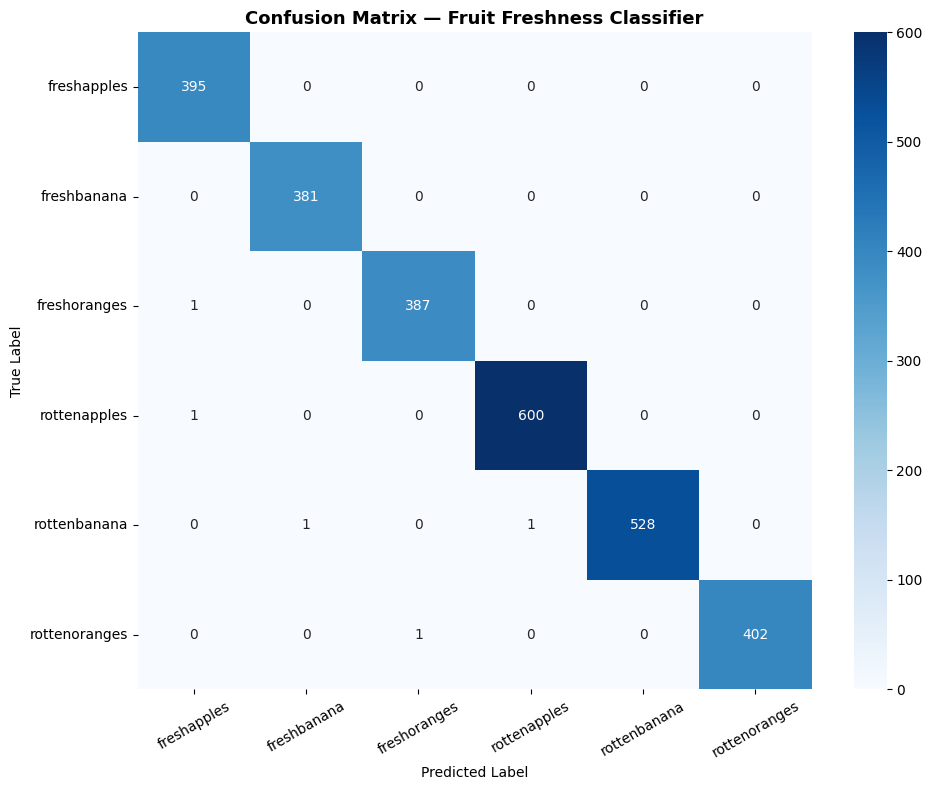

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — Fruit Freshness Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

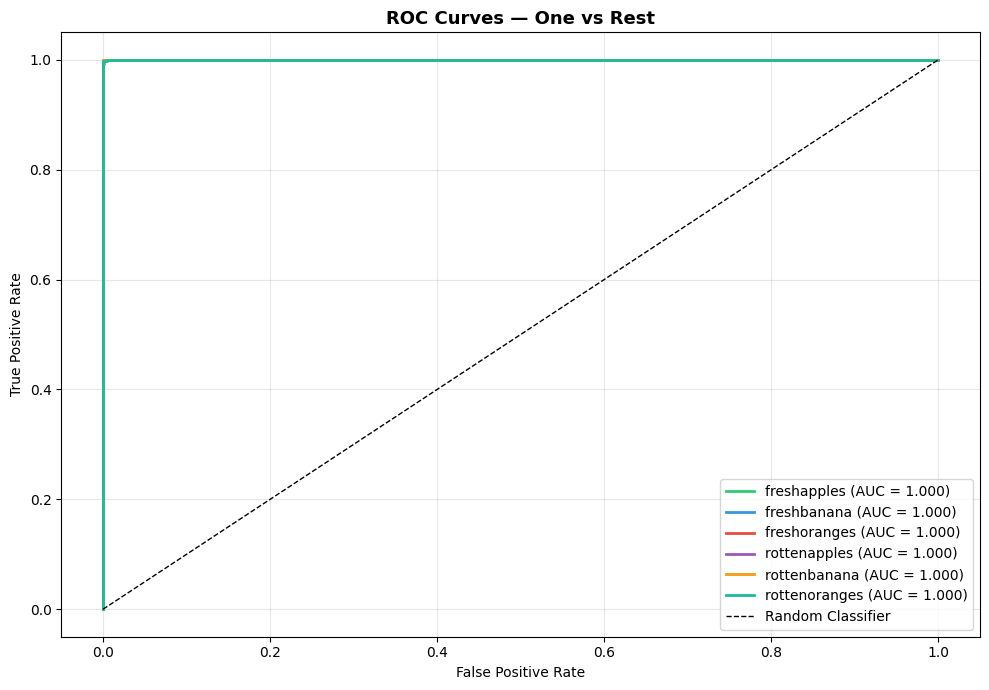

In [26]:
# ROC Curves (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 7))
colors_roc = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12','#1abc9c']

for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auc_score   = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {auc_score:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One vs Rest', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## 9. Model Testing — Single Image Prediction

Testing with image from class: freshoranges


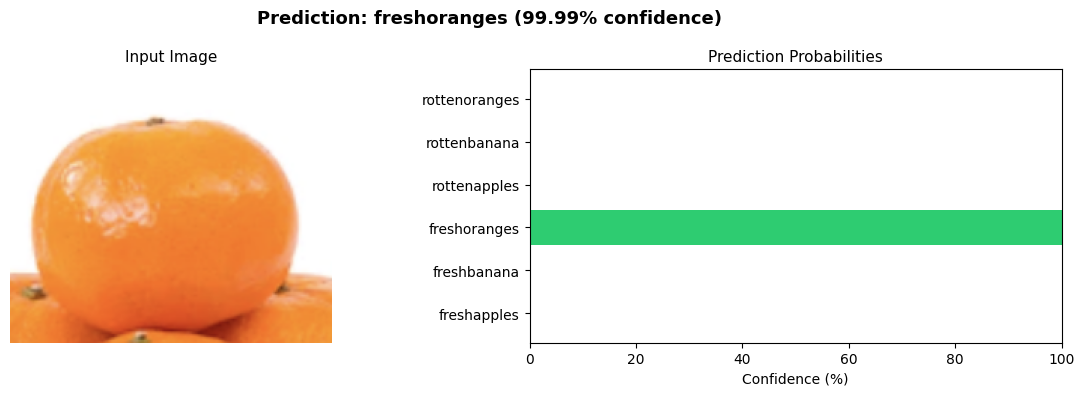

In [27]:
def predict_image(model, image_path, class_names, img_size=(224, 224)):
    """Predict freshness class for a single image."""
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    predictions = model.predict(img_array, verbose=0)
    predicted_idx   = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    confidence      = predictions[0][predicted_idx] * 100

    # Display result
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Input Image', fontsize=11)
    axes[0].axis('off')

    colors_bar = ['#2ecc71' if p == max(predictions[0]) else '#bdc3c7' for p in predictions[0]]
    axes[1].barh(class_names, predictions[0] * 100, color=colors_bar)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Prediction Probabilities', fontsize=11)
    axes[1].set_xlim(0, 100)

    plt.suptitle(f'Prediction: {predicted_class} ({confidence:.2f}% confidence)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence, predictions[0].tolist()

# Test with a sample image
sample_class = random.choice(class_names)
sample_dir   = os.path.join(TEST_DIR, sample_class)
sample_img   = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))

print(f'Testing with image from class: {sample_class}')
pred_class, confidence, probs = predict_image(model, sample_img, class_names)

## 10. Model Retraining Setup

In [28]:
def retrain_model(model, new_data_dir, epochs=5, learning_rate=1e-5):
    """
    Retrain the model on new uploaded data.
    This function is called by the FastAPI /retrain endpoint.

    Args:
        model: Existing Keras model
        new_data_dir: Directory containing new training images (organized by class)
        epochs: Number of retraining epochs
        learning_rate: Learning rate for retraining

    Returns:
        dict: Retraining metrics
    """
    retrain_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        validation_split=0.2
    )

    retrain_gen = retrain_datagen.flow_from_directory(
        new_data_dir,
        target_size=IMG_SIZE,
        batch_size=16,
        class_mode='categorical',
        subset='training',
        seed=SEED
    )

    retrain_val_gen = retrain_datagen.flow_from_directory(
        new_data_dir,
        target_size=IMG_SIZE,
        batch_size=16,
        class_mode='categorical',
        subset='validation',
        seed=SEED
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    retrain_history = model.fit(
        retrain_gen,
        epochs=epochs,
        validation_data=retrain_val_gen,
        verbose=1
    )

    # Save updated model
    model.save('models/fruit_model_retrained.h5')
    print('Model retrained and saved to models/fruit_model_retrained.h5')

    return {
        'final_train_accuracy': retrain_history.history['accuracy'][-1],
        'final_val_accuracy':   retrain_history.history['val_accuracy'][-1],
        'epochs_run': len(retrain_history.history['accuracy'])
    }

print('Retrain function defined and ready.')
print('This will be triggered via the FastAPI /retrain endpoint in production.')

Retrain function defined and ready.
This will be triggered via the FastAPI /retrain endpoint in production.


## 11. Save Final Model

In [30]:
import os
import json

SAVE_DIR = '/content/drive/MyDrive/MLPOS/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save in native Keras format (recommended)
model.save(f'{SAVE_DIR}/fruit_model.keras')

# Save class names
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f)

print('Model saved to Drive!')
print(f'  → {SAVE_DIR}/fruit_model.keras')
print(f'  → {SAVE_DIR}/class_names.json')
print(f'\nFinal Test Accuracy: {test_accuracy*100:.2f}%')

Model saved to Drive!
  → /content/drive/MyDrive/MLPOS/models/fruit_model.keras
  → /content/drive/MyDrive/MLPOS/models/class_names.json

Final Test Accuracy: 99.81%
